In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Predicted Values:
[0 1 1 0 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 0
 0 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 0 1
 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
Actual Values:
[0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0
 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0
 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1
 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1]
Accuracy: 0.703125


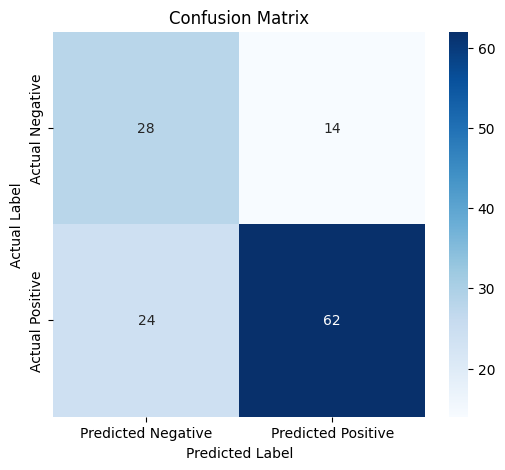

TP = 62
TN = 28
FP = 14
FN = 24


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_data = pd.read_csv('/content/drive/MyDrive/ML/dataset12 (1).csv')

test_data = pd.read_csv('/content/drive/MyDrive/ML/testdata12 (1).csv')

X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

print("Actual Values:")
print(y_test.values)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)